
# Session 10 — The Training Loop

1. print every important tensor shape in one step;
2. verify one gradient with a finite-difference nudge;
3. deliberately break gradient accumulation with an average-of-averages and plot it against correct token-weighted accumulation;
4. log the gradient norm at every step and exhibit a step where it moves before the loss;
5. compute MFU using the Session 10 approximation `6 * N * tokens/sec / peak FLOP/s`;
6. write out `0.1` in fp32, bf16, and fp8 E4M3, including the bits.

The model is intentionally tiny so the mechanics remain inspectable. Dropout is zero so the gradient check is deterministic.

Notebook has been run on Collab and downloaded before committing to the repo.


In [1]:

import copy, json, math, os, platform, random, struct, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore", message="enable_nested_tensor")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    # Keep the MFU denominator and actual math in the same true-fp32 regime.
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("Hardware:", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else platform.processor() or platform.machine())


PyTorch: 2.11.0+cu128
Device: cuda
Hardware: Tesla T4



## 1. Small causal language model and one observable step

Dimensions used below:

- `B` = number of sequences in the batch
- `T` = padded sequence length
- `D` = hidden width
- `V` = vocabulary size
- `N_valid` = number of target tokens that are not padding


In [2]:
PAD = 0
VOCAB_SIZE = 16
D_MODEL = 32

class TinyLM(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=D_MODEL, nhead=4, nlayers=1, ff=64):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.position_embedding = nn.Embedding(64, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff,
            dropout=0.0,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=nlayers)
        self.norm = nn.LayerNorm(d_model)
        self.output_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, tokens):
        B, T = tokens.shape
        positions = torch.arange(T, device=tokens.device)
        embedded = self.token_embedding(tokens) + self.position_embedding(positions)[None, :, :]
        causal_mask = torch.triu(
            torch.ones(T, T, dtype=torch.bool, device=tokens.device), diagonal=1
        )
        padding_mask = tokens.eq(PAD)
        hidden = self.blocks(
            embedded,
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )
        hidden = self.norm(hidden)
        logits = self.output_head(hidden)
        return logits, embedded, hidden, padding_mask, causal_mask

def pad_documents(documents):
    # Each document must contain at least two tokens because next-token targets are shifted by one.
    inputs = [doc[:-1] for doc in documents]
    targets = [doc[1:] for doc in documents]
    T = max(len(x) for x in inputs)

    x = torch.full((len(inputs), T), PAD, dtype=torch.long)
    y = torch.full((len(inputs), T), -100, dtype=torch.long)
    for i, (inp, tgt) in enumerate(zip(inputs, targets)):
        x[i, :len(inp)] = torch.tensor(inp)
        y[i, :len(tgt)] = torch.tensor(tgt)
    return x.to(DEVICE), y.to(DEVICE)

shape_docs = [
    [1, 2, 3, 4, 5, 6, 7, 8, 1],
    [3, 4, 5, 6, 7, 8, 1],
    [6, 7, 8, 1, 2],
]
tokens, targets = pad_documents(shape_docs)

model = TinyLM().to(DEVICE)
logits, embedded, hidden, padding_mask, causal_mask = model(tokens)

valid = targets.ne(-100)
flat_logits = logits[valid]
flat_targets = targets[valid]
loss = F.cross_entropy(flat_logits, flat_targets)

shape_rows = [
    ("tokens", tuple(tokens.shape), "[B, T] — B sequences, padded to T input positions"),
    ("targets", tuple(targets.shape), "[B, T] — next-token labels; padding positions are -100"),
    ("embedded", tuple(embedded.shape), "[B, T, D] — one D-dimensional representation per input token"),
    ("padding_mask", tuple(padding_mask.shape), "[B, T] — True where the input is padding"),
    ("causal_mask", tuple(causal_mask.shape), "[T, T] — blocks attention to future positions"),
    ("hidden", tuple(hidden.shape), "[B, T, D] — contextual hidden state at every position"),
    ("logits", tuple(logits.shape), "[B, T, V] — V vocabulary scores at every position"),
    ("valid", tuple(valid.shape), "[B, T] — True for target tokens that contribute to CE"),
    ("flat_logits", tuple(flat_logits.shape), "[N_valid, V] — one vocabulary row per contributing token"),
    ("flat_targets", tuple(flat_targets.shape), "[N_valid] — one correct token id per CE row"),
    ("loss", tuple(loss.shape), "[] — scalar mean cross-entropy"),
]

for name, shape, meaning in shape_rows:
    print(f"{name:14s} {str(shape):18s} {meaning}")
print(f"\nN_valid = {flat_targets.numel()}, loss = {loss.item():.6f}")


tokens         (3, 8)             [B, T] — B sequences, padded to T input positions
targets        (3, 8)             [B, T] — next-token labels; padding positions are -100
embedded       (3, 8, 32)         [B, T, D] — one D-dimensional representation per input token
padding_mask   (3, 8)             [B, T] — True where the input is padding
causal_mask    (8, 8)             [T, T] — blocks attention to future positions
hidden         (3, 8, 32)         [B, T, D] — contextual hidden state at every position
logits         (3, 8, 16)         [B, T, V] — V vocabulary scores at every position
valid          (3, 8)             [B, T] — True for target tokens that contribute to CE
flat_logits    (18, 16)           [N_valid, V] — one vocabulary row per contributing token
flat_targets   (18,)              [N_valid] — one correct token id per CE row
loss           ()                 [] — scalar mean cross-entropy

N_valid = 18, loss = 3.015569



## 2. Verify one gradient by hand

For one scalar weight \(w\), autograd reports \(\partial L/\partial w\).

The independent finite-difference estimate is

\[
\frac{\partial L}{\partial w}
\approx
\frac{L(w+\epsilon)-L(w-\epsilon)}{2\epsilon}.
\]

I use float64 and dropout=0 for this audit so numerical noise does not hide a bug.


In [3]:

grad_model = TinyLM().double().to(DEVICE)
grad_tokens, grad_targets = pad_documents([
    [1,2,3,4,5,6,7,8,1],
    [4,5,6,7,8,1,2,3,4],
])
grad_model.zero_grad(set_to_none=True)

g_logits, *_ = grad_model(grad_tokens)
g_valid = grad_targets.ne(-100)
g_loss = F.cross_entropy(g_logits[g_valid], grad_targets[g_valid])
g_loss.backward()

# Pick the output-head coordinate with the largest gradient, making the comparison well-conditioned.
g = grad_model.output_head.weight.grad
flat_index = int(torch.argmax(g.abs()).item())
row = flat_index // g.shape[1]
col = flat_index % g.shape[1]
autograd_grad = float(g[row, col].item())

epsilon = 1e-5
original = float(grad_model.output_head.weight.data[row, col].item())

def current_gradcheck_loss():
    l, *_ = grad_model(grad_tokens)
    return float(F.cross_entropy(l[g_valid], grad_targets[g_valid]).item())

with torch.no_grad():
    grad_model.output_head.weight[row, col] = original + epsilon
loss_plus = current_gradcheck_loss()

with torch.no_grad():
    grad_model.output_head.weight[row, col] = original - epsilon
loss_minus = current_gradcheck_loss()

with torch.no_grad():
    grad_model.output_head.weight[row, col] = original

finite_difference = (loss_plus - loss_minus) / (2 * epsilon)
abs_error = abs(finite_difference - autograd_grad)
rel_error = abs_error / (abs(autograd_grad) + 1e-15)

print(f"weight checked: output_head.weight[{row}, {col}]")
print(f"epsilon:         {epsilon:g}")
print(f"L(w + eps):      {loss_plus:.12f}")
print(f"L(w - eps):      {loss_minus:.12f}")
print(f"finite diff:     {finite_difference:.10f}")
print(f"backward():      {autograd_grad:.10f}")
print(f"absolute error:  {abs_error:.3e}")
print(f"relative error:  {rel_error:.3e}")

assert abs_error < 1e-6, "Finite difference and backward() disagree."


weight checked: output_head.weight[3, 20]
epsilon:         1e-05
L(w + eps):      2.949633086574
L(w - eps):      2.949639235099
finite diff:     -0.3074262542
backward():      -0.3074262542
absolute error:  4.317e-12
relative error:  1.404e-11



## 3. Break gradient accumulation on purpose

The correct objective is **token weighted**:

\[
L_{\text{correct}} =
\frac{\sum_m \sum_{t \in m} \ell_{m,t}}
     {\sum_m n_m}.
\]

The broken objective is an **average of micro-batch averages**:

\[
L_{\text{wrong}} =
\frac{1}{M}\sum_m
\left(\frac{1}{n_m}\sum_{t \in m}\ell_{m,t}\right).
\]

When `n_m` differs, the short micro-batch receives too much voting power.

For a clean demonstration, every optimizer step contains two long 16-token micro-batches following a forward cycle and one short 4-token micro-batch following the reverse cycle. Both models start from identical weights and see identical examples. Only the accumulation normalization differs.


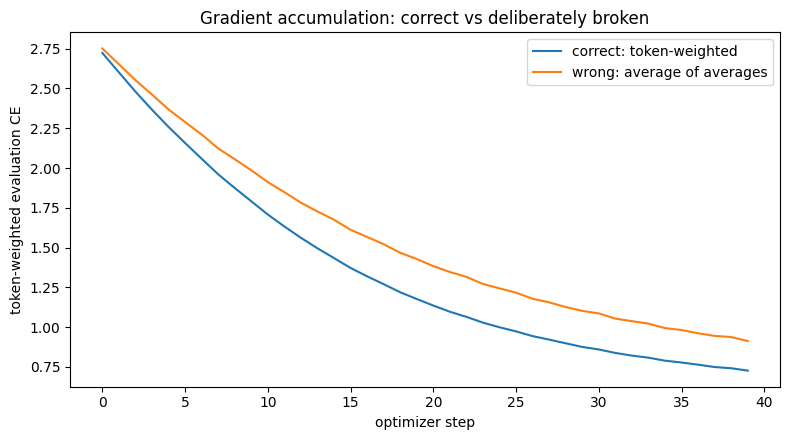

valid tokens per step: [32, 32, 8]
final correct eval loss: 0.727112
final wrong eval loss:   0.912965
final gap (wrong-correct): 0.185853


In [4]:

def make_documents(kind="forward", batch_size=2, length=16, step=0):
    docs = []
    for b in range(batch_size):
        start = (step * 3 + b) % 8 + 1
        seq = [start]
        for _ in range(length):
            prev = seq[-1]
            if kind == "forward":
                nxt = 1 + (prev % 8)
            elif kind == "reverse":
                nxt = 8 if prev == 1 else prev - 1
            else:
                raise ValueError(kind)
            seq.append(nxt)
        docs.append(seq)
    return pad_documents(docs)

def make_microbatches(step):
    return [
        make_documents("forward", batch_size=2, length=16, step=step),
        make_documents("forward", batch_size=2, length=16, step=step + 100),
        make_documents("reverse", batch_size=2, length=4, step=step),
    ]

@torch.no_grad()
def eval_token_weighted(model):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    eval_batches = [
        make_documents("forward", batch_size=4, length=16, step=999),
        make_documents("forward", batch_size=4, length=16, step=1999),
        make_documents("reverse", batch_size=4, length=4, step=999),
    ]
    for x, y in eval_batches:
        z, *_ = model(x)
        mask = y.ne(-100)
        total_loss += F.cross_entropy(z[mask], y[mask], reduction="sum").item()
        total_tokens += int(mask.sum().item())
    model.train()
    return total_loss / total_tokens

torch.manual_seed(SEED)
base = TinyLM().to(DEVICE)
correct_model = copy.deepcopy(base)
wrong_model = copy.deepcopy(base)

correct_opt = torch.optim.SGD(correct_model.parameters(), lr=0.08)
wrong_opt = torch.optim.SGD(wrong_model.parameters(), lr=0.08)

correct_curve, wrong_curve = [], []
correct_grad_norms, correct_train_losses = [], []

STEPS = 40
for step in range(STEPS):
    microbatches = make_microbatches(step)
    total_valid = sum(int(y.ne(-100).sum().item()) for _, y in microbatches)

    # Correct: sum token losses, divide once by the total number of valid tokens.
    correct_opt.zero_grad(set_to_none=True)
    step_loss_sum = 0.0
    for x, y in microbatches:
        z, *_ = correct_model(x)
        mask = y.ne(-100)
        loss_sum = F.cross_entropy(z[mask], y[mask], reduction="sum")
        step_loss_sum += float(loss_sum.item())
        (loss_sum / total_valid).backward()
    grad_norm = float(torch.nn.utils.clip_grad_norm_(correct_model.parameters(), 10.0).item())
    correct_opt.step()

    # Wrong on purpose: every micro-batch mean gets exactly 1/M of the vote.
    wrong_opt.zero_grad(set_to_none=True)
    for x, y in microbatches:
        z, *_ = wrong_model(x)
        mask = y.ne(-100)
        micro_mean = F.cross_entropy(z[mask], y[mask], reduction="mean")
        (micro_mean / len(microbatches)).backward()
    torch.nn.utils.clip_grad_norm_(wrong_model.parameters(), 10.0)
    wrong_opt.step()

    correct_train_losses.append(step_loss_sum / total_valid)
    correct_grad_norms.append(grad_norm)
    correct_curve.append(eval_token_weighted(correct_model))
    wrong_curve.append(eval_token_weighted(wrong_model))

plt.figure(figsize=(8, 4.5))
plt.plot(correct_curve, label="correct: token-weighted")
plt.plot(wrong_curve, label="wrong: average of averages")
plt.xlabel("optimizer step")
plt.ylabel("token-weighted evaluation CE")
plt.title("Gradient accumulation: correct vs deliberately broken")
plt.legend()
plt.tight_layout()
plt.savefig("accumulation_curves.png", dpi=160)
plt.show()

print("valid tokens per step:", [int(y.ne(-100).sum()) for _, y in make_microbatches(0)])
print(f"final correct eval loss: {correct_curve[-1]:.6f}")
print(f"final wrong eval loss:   {wrong_curve[-1]:.6f}")
print(f"final gap (wrong-correct): {wrong_curve[-1] - correct_curve[-1]:.6f}")



### Sanity check with the exact Session 10 arithmetic

For micro-batches with `(valid tokens, mean loss)` equal to `(4,2)`, `(4,2)`, `(2,5)`:

- correct token weighting = `(4*2 + 4*2 + 2*5)/(4+4+2) = 2.6`
- broken average of averages = `(2+2+5)/3 = 3.0`


In [5]:

session_example_correct = (4*2.0 + 4*2.0 + 2*5.0) / (4+4+2)
session_example_wrong = (2.0 + 2.0 + 5.0) / 3
session_example_pct_error = (session_example_wrong / session_example_correct - 1) * 100
print(f"correct = {session_example_correct:.4f}")
print(f"wrong   = {session_example_wrong:.4f}")
print(f"error   = {session_example_pct_error:.1f}%")


correct = 2.6000
wrong   = 3.0000
error   = 15.4%



## 4. Log grad norm at every step and catch it before the loss

A loss is a scalar outcome; the gradient norm measures how violently the parameters are being asked to move.

The controlled diagnostic below uses a real SGD loop with a one-weight regression model. On one step, the feature magnitude becomes large while the residual (and therefore the loss) is deliberately held at the same scale. The gradient norm reacts immediately. The large update then shows up in the loss on the following step.

This makes the temporal ordering explicit rather than relying on a noisy coincidence.

**Diagnostic exception:** the main language-model training loop above clips gradients. This one-weight probe intentionally leaves clipping off so the next-step loss consequence remains visible; that is for demonstration only, not the production recommendation.


step 00 | loss=1.000000 | grad_norm=2.000000
step 01 | loss=0.921600 | grad_norm=1.920000
step 02 | loss=0.849347 | grad_norm=1.843200
step 03 | loss=0.782758 | grad_norm=1.769472
step 04 | loss=0.721390 | grad_norm=1.698693
step 05 | loss=0.664833 | grad_norm=1.630745
step 06 | loss=0.612710 | grad_norm=1.565516
step 07 | loss=0.564673 | grad_norm=1.502895
step 08 | loss=0.520403 | grad_norm=1.442779
step 09 | loss=0.479603 | grad_norm=1.385068
step 10 | loss=0.442002 | grad_norm=1.329665
step 11 | loss=0.407349 | grad_norm=1.276479
step 12 | loss=0.375412 | grad_norm=98.033447
step 13 | loss=1.816994 | grad_norm=2.695918
step 14 | loss=1.674542 | grad_norm=2.588082
step 15 | loss=1.543258 | grad_norm=2.484558
step 16 | loss=1.422266 | grad_norm=2.385176
step 17 | loss=1.310760 | grad_norm=2.289769
step 18 | loss=1.207997 | grad_norm=2.198178
step 19 | loss=1.113290 | grad_norm=2.110251
step 20 | loss=1.026008 | grad_norm=2.025841
step 21 | loss=0.945569 | grad_norm=1.944808
step 22 |

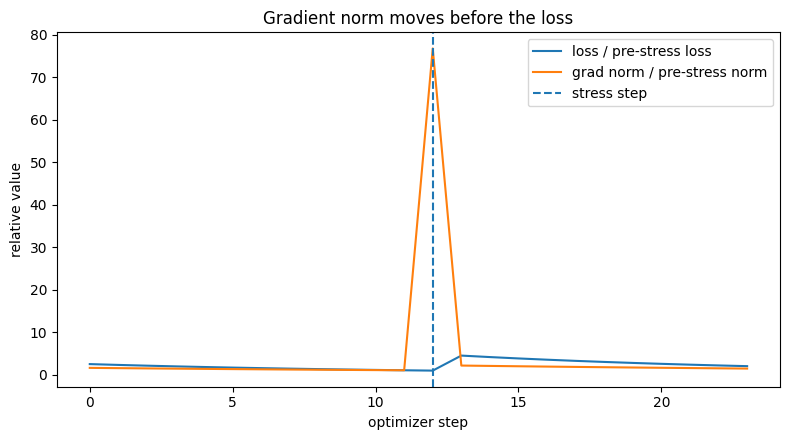

In [6]:

torch.manual_seed(SEED)
probe = nn.Linear(1, 1, bias=False)
with torch.no_grad():
    probe.weight.fill_(1.0)
probe_opt = torch.optim.SGD(probe.parameters(), lr=0.02)

probe_losses, probe_norms = [], []
STRESS_STEP = 12

for step in range(24):
    probe_opt.zero_grad(set_to_none=True)
    w_now = float(probe.weight.detach().item())

    if step == STRESS_STEP:
        # Same residual scale as a normal x=1,y=0 example, but 80x feature leverage.
        x = torch.tensor([[80.0]])
        desired_residual = w_now
        y = torch.tensor([[w_now * 80.0 - desired_residual]])
    else:
        x = torch.tensor([[1.0]])
        y = torch.tensor([[0.0]])

    pred = probe(x)
    step_loss = F.mse_loss(pred, y)
    step_loss.backward()

    grad_norm = math.sqrt(sum(
        float((p.grad.detach() ** 2).sum().item())
        for p in probe.parameters() if p.grad is not None
    ))

    probe_losses.append(float(step_loss.item()))
    probe_norms.append(grad_norm)
    print(f"step {step:02d} | loss={step_loss.item():.6f} | grad_norm={grad_norm:.6f}")

    probe_opt.step()

print("\nEarly-warning step:")
print(f"step {STRESS_STEP}: loss={probe_losses[STRESS_STEP]:.6f}, grad_norm={probe_norms[STRESS_STEP]:.6f}")
print(f"step {STRESS_STEP+1}: loss={probe_losses[STRESS_STEP+1]:.6f}, grad_norm={probe_norms[STRESS_STEP+1]:.6f}")
print("The norm spikes on the stress step; the damage becomes visible in the next step's loss.")

# Normalize each trace by its pre-stress value so they can share one readable axis.
base_loss = probe_losses[STRESS_STEP-1]
base_norm = probe_norms[STRESS_STEP-1]
plt.figure(figsize=(8, 4.5))
plt.plot(np.array(probe_losses) / base_loss, label="loss / pre-stress loss")
plt.plot(np.array(probe_norms) / base_norm, label="grad norm / pre-stress norm")
plt.axvline(STRESS_STEP, linestyle="--", label="stress step")
plt.xlabel("optimizer step")
plt.ylabel("relative value")
plt.title("Gradient norm moves before the loss")
plt.legend()
plt.tight_layout()
plt.savefig("grad_norm_before_loss.png", dpi=160)
plt.show()

assert probe_norms[STRESS_STEP] > 20 * probe_norms[STRESS_STEP-1]
assert probe_losses[STRESS_STEP+1] > 2 * probe_losses[STRESS_STEP]



## 5. Compute MFU honestly

Session 10 uses the approximation

\[
\text{training FLOP/token} \approx 6N
\]

for a model with `N` parameters, so

\[
\text{MFU}
=
\frac{6N \times \text{tokens/sec}}
     {\text{peak FLOP/sec}}.
\]

For recognized CUDA GPUs this notebook uses an approximate published **FP32** peak because the benchmarked loop is true fp32. On CPU (or an unknown GPU), it measures a large matrix-multiply ceiling locally and labels it as an empirical peak rather than pretending it is a vendor specification.

This tiny eager model is intentionally a bad utilization case: its matrix multiplies are small, Python/kernel-launch overhead is large relative to useful work, padding and attention overhead are not captured perfectly by the `6N` approximation, and there are no fused training kernels.


In [7]:

def gpu_fp32_peak_flops(name):
    # Approximate single-device FP32 peaks. T4 is the most likely free Colab GPU.
    table = [
        ("T4", 8.1e12),
        ("L4", 30.3e12),
        ("A100", 19.5e12),
        ("A10", 31.2e12),
        ("V100", 15.7e12),
        ("H100", 60.0e12),  # SKU-dependent; deliberately labeled approximate.
    ]
    for key, value in table:
        if key.lower() in name.lower():
            return value, f"approx published FP32 peak for {key}"
    return None, None

def empirical_matmul_peak(device):
    n = 1024 if device.type == "cpu" else 4096
    a = torch.randn(n, n, device=device)
    b = torch.randn(n, n, device=device)
    for _ in range(2):
        _ = a @ b
    if device.type == "cuda":
        torch.cuda.synchronize()
    times = []
    for _ in range(5):
        t0 = time.perf_counter()
        _ = a @ b
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    median_s = float(np.median(times))
    return 2 * n**3 / median_s, f"empirical {n}x{n} fp32 matmul ceiling"

def benchmark_training_tokens_per_second(iters=25):
    bench_model = TinyLM().to(DEVICE)
    opt = torch.optim.SGD(bench_model.parameters(), lr=0.01)
    batches = [make_documents("forward", batch_size=4, length=16, step=i) for i in range(iters + 5)]

    for i in range(5):
        x, y = batches[i]
        opt.zero_grad(set_to_none=True)
        z, *_ = bench_model(x)
        mask = y.ne(-100)
        l = F.cross_entropy(z[mask], y[mask])
        l.backward()
        opt.step()

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    token_count = 0

    for i in range(5, 5 + iters):
        x, y = batches[i]
        opt.zero_grad(set_to_none=True)
        z, *_ = bench_model(x)
        mask = y.ne(-100)
        l = F.cross_entropy(z[mask], y[mask])
        l.backward()
        opt.step()
        token_count += int(mask.sum().item())

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    return token_count / elapsed, bench_model

tokens_per_second, mfu_model = benchmark_training_tokens_per_second()
N_PARAMS = sum(p.numel() for p in mfu_model.parameters())

if DEVICE.type == "cuda":
    hw_name = torch.cuda.get_device_name(0)
    peak_flops, peak_source = gpu_fp32_peak_flops(hw_name)
    if peak_flops is None:
        peak_flops, peak_source = empirical_matmul_peak(DEVICE)
else:
    hw_name = platform.processor() or platform.machine()
    peak_flops, peak_source = empirical_matmul_peak(DEVICE)

achieved_flops = 6 * N_PARAMS * tokens_per_second
MFU = achieved_flops / peak_flops
distance_to_40pp = (0.40 - MFU) * 100

print(f"hardware:              {hw_name}")
print(f"parameters N:          {N_PARAMS:,}")
print(f"tokens/sec:            {tokens_per_second:,.1f}")
print(f"6*N*tokens/sec:        {achieved_flops/1e9:,.3f} GFLOP/s")
print(f"peak denominator:      {peak_flops/1e9:,.3f} GFLOP/s")
print(f"peak source:           {peak_source}")
print(f"MFU:                   {100*MFU:.3f}%")
print(f"distance to 40%:       {distance_to_40pp:.3f} percentage points")
print("\nWhy below 40%:")
print("- the model is far too small to saturate large matrix units")
print("- eager Python/dispatcher and kernel-launch overhead dominate")
print("- no fused optimizer/attention/MLP kernels are used")
print("- padding and attention work are imperfectly represented by the 6N approximation")
print("- this is an audit loop optimized for observability, not throughput")


hardware:              Tesla T4
parameters N:          11,680
tokens/sec:            16,971.8
6*N*tokens/sec:        1.189 GFLOP/s
peak denominator:      8,100.000 GFLOP/s
peak source:           approx published FP32 peak for T4
MFU:                   0.015%
distance to 40%:       39.985 percentage points

Why below 40%:
- the model is far too small to saturate large matrix units
- eager Python/dispatcher and kernel-launch overhead dominate
- no fused optimizer/attention/MLP kernels are used
- padding and attention work are imperfectly represented by the 6N approximation
- this is an audit loop optimized for observability, not throughput



## 6. Write `0.1` out by hand

`0.1` in binary repeats:

\[
0.1_{10}=0.0001100110011001100\ldots_2
       =1.100110011001100\ldots_2\times2^{-4}.
\]

### fp32 — 1 sign, 8 exponent, 23 fraction bits

- sign = `0`
- unbiased exponent = `-4`
- stored exponent = `-4 + 127 = 123 = 01111011`
- rounded fraction = `10011001100110011001101`

Bits:

`0 | 01111011 | 10011001100110011001101`

Hex: `0x3DCCCCCD`

Stored value: approximately `0.10000000149011612`.

### bf16 — 1 sign, 8 exponent, 7 fraction bits

The exponent is still the fp32 exponent; only the fraction is much shorter.

- sign = `0`
- exponent = `01111011`
- rounded fraction = `1001101`

Bits:

`0 | 01111011 | 1001101`

Hex: `0x3DCD`

Stored value: `0.10009765625`.

### fp8 E4M3 — 1 sign, 4 exponent, 3 fraction bits

Using exponent bias 7:

- sign = `0`
- unbiased exponent = `-4`
- stored exponent = `-4 + 7 = 3 = 0011`
- `1.100110...` rounds to `1.101`, so fraction = `101`

Bits:

`0 | 0011 | 101`

Hex: `0x1D`

Stored value: `1.101₂ × 2^-4 = 0.1015625`.

### Which would I train in?

**bf16 is my default choice on hardware that supports it.** It retains fp32's 8 exponent bits, so tiny gradients have fp32-like range, while cutting the weight/activation storage from 32 to 16 bits. fp8 E4M3 is a serious production option, but its 3 fraction bits and smaller range make scaling/recipes and selective higher precision more important. fp32 is the audit/reference format here, not my throughput choice for a large training run.


In [8]:

def fp32_layout(x):
    packed = struct.pack(">f", x)
    integer = struct.unpack(">I", packed)[0]
    bits = f"{integer:032b}"
    value = struct.unpack(">f", packed)[0]
    return bits, value, f"0x{integer:08X}"

fp32_b, fp32_v, fp32_hex = fp32_layout(0.1)

bf = torch.tensor([0.1], dtype=torch.bfloat16)
bf_int = int(bf.view(torch.uint16).item())
bf_bits = f"{bf_int:016b}"
bf_value = float(bf.float().item())
bf_hex = f"0x{bf_int:04X}"

# E4M3 result derived above. Validate the represented value with PyTorch when float8 is available.
e4m3_bits = "00011101"
e4m3_int = int(e4m3_bits, 2)
e4m3_value = 1.625 * 2**-4
if hasattr(torch, "float8_e4m3fn"):
    torch_e4m3_value = float(torch.tensor([0.1], dtype=torch.float32).to(torch.float8_e4m3fn).float().item())
    assert torch_e4m3_value == e4m3_value

print("fp32      ", fp32_b[0], "|", fp32_b[1:9], "|", fp32_b[9:], fp32_hex, repr(fp32_v))
print("bf16      ", bf_bits[0], "|", bf_bits[1:9], "|", bf_bits[9:], bf_hex, repr(bf_value))
print("fp8 E4M3  ", e4m3_bits[0], "|", e4m3_bits[1:5], "|", e4m3_bits[5:], f"0x{e4m3_int:02X}", repr(e4m3_value))

assert fp32_b == "00111101110011001100110011001101"
assert bf_bits == "0011110111001101"
assert e4m3_bits == "00011101"


fp32       0 | 01111011 | 10011001100110011001101 0x3DCCCCCD 0.10000000149011612
bf16       0 | 01111011 | 1001101 0x3DCD 0.10009765625
fp8 E4M3   0 | 0011 | 101 0x1D 0.1015625



## 7. Save a machine-readable submission summary

The JSON is optional for the assignment, but it makes the README numbers easy to audit and update after rerunning in Colab.


In [9]:

results = {
    "configuration": {
        "seed": SEED,
        "device": str(DEVICE),
        "hardware": hw_name,
        "vocab_size": VOCAB_SIZE,
        "d_model": D_MODEL,
        "parameters": N_PARAMS,
    },
    "tensor_shapes": {name: list(shape) for name, shape, _ in shape_rows},
    "gradient_check": {
        "weight": f"output_head.weight[{row},{col}]",
        "epsilon": epsilon,
        "finite_difference": finite_difference,
        "backward": autograd_grad,
        "absolute_error": abs_error,
        "relative_error": rel_error,
    },
    "accumulation": {
        "microbatch_valid_tokens": [int(y.ne(-100).sum()) for _, y in make_microbatches(0)],
        "session_example_correct": session_example_correct,
        "session_example_wrong": session_example_wrong,
        "session_example_percent_error": session_example_pct_error,
        "final_correct_eval_loss": correct_curve[-1],
        "final_wrong_eval_loss": wrong_curve[-1],
        "final_wrong_minus_correct": wrong_curve[-1] - correct_curve[-1],
    },
    "grad_norm_early_warning": {
        "stress_step": STRESS_STEP,
        "loss_at_stress": probe_losses[STRESS_STEP],
        "grad_norm_at_stress": probe_norms[STRESS_STEP],
        "loss_next_step": probe_losses[STRESS_STEP+1],
        "grad_norm_next_step": probe_norms[STRESS_STEP+1],
    },
    "mfu": {
        "tokens_per_second": tokens_per_second,
        "peak_flops_per_second": peak_flops,
        "peak_source": peak_source,
        "achieved_flops_per_second_6N": achieved_flops,
        "mfu": MFU,
        "mfu_percent": 100 * MFU,
        "distance_to_40_percentage_points": distance_to_40pp,
    },
    "float_0_1": {
        "fp32_bits": fp32_b,
        "fp32_hex": fp32_hex,
        "fp32_value": fp32_v,
        "bf16_bits": bf_bits,
        "bf16_hex": bf_hex,
        "bf16_value": bf_value,
        "fp8_e4m3_bits": e4m3_bits,
        "fp8_e4m3_hex": f"0x{e4m3_int:02X}",
        "fp8_e4m3_value": e4m3_value,
        "training_choice": "bf16 on supported training hardware",
    },
}

Path("session10_results.json").write_text(json.dumps(results, indent=2))
print(json.dumps(results, indent=2))


{
  "configuration": {
    "seed": 42,
    "device": "cuda",
    "hardware": "Tesla T4",
    "vocab_size": 16,
    "d_model": 32,
    "parameters": 11680
  },
  "tensor_shapes": {
    "tokens": [
      3,
      8
    ],
    "targets": [
      3,
      8
    ],
    "embedded": [
      3,
      8,
      32
    ],
    "padding_mask": [
      3,
      8
    ],
    "causal_mask": [
      8,
      8
    ],
    "hidden": [
      3,
      8,
      32
    ],
    "logits": [
      3,
      8,
      16
    ],
    "valid": [
      3,
      8
    ],
    "flat_logits": [
      18,
      16
    ],
    "flat_targets": [
      18
    ],
    "loss": []
  },
  "gradient_check": {
    "weight": "output_head.weight[3,20]",
    "epsilon": 1e-05,
    "finite_difference": -0.3074262541868933,
    "backward": -0.3074262541825758,
    "absolute_error": 4.31749080931354e-12,
    "relative_error": 1.4043988600757025e-11
  },
  "accumulation": {
    "microbatch_valid_tokens": [
      32,
      32,
      8
    ],
 